In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from scipy.stats import norm

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/sarthaksoni25/Rossmann-Store-Sales-Prediction/refs/heads/master/dataset/train.csv', low_memory=False)

In [ ]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001599 entries, 0 to 1001598
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1001599 non-null  int64 
 1   DayOfWeek      1001599 non-null  int64 
 2   Date           1001599 non-null  object
 3   Sales          1001599 non-null  int64 
 4   Customers      1001599 non-null  int64 
 5   Open           1001599 non-null  int64 
 6   Promo          1001599 non-null  int64 
 7   StateHoliday   1001599 non-null  object
 8   SchoolHoliday  1001599 non-null  int64 
 9   Id             1001599 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 76.4+ MB


In [ ]:
df.drop(columns=['Store', 'Id'], inplace=True)

In [ ]:
print("Shape:", df.shape)

Shape: (1001599, 8)


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df_open = df[df['Open'] == 1].copy()

In [ ]:
df_open.drop(columns=['Open'], inplace=True)

In [ ]:
df_open.head()

,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
1000837,2,2013-01-01,3139,820,0,a,1
1000819,2,2013-01-01,2401,482,0,a,1
1000996,2,2013-01-01,2646,625,0,a,1
1000978,2,2013-01-01,3113,527,0,a,1
1001014,2,2013-01-01,2907,532,0,a,1


In [ ]:
df_open.tail(5)

,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
745,5,2015-07-17,7310,572,1,0,0
746,5,2015-07-17,8467,702,1,0,1
747,5,2015-07-17,5232,469,1,0,1
741,5,2015-07-17,7767,777,1,0,1
0,5,2015-07-17,4852,519,1,0,0


In [ ]:
cols = ['SchoolHoliday', 'Promo', 'DayOfWeek', 'StateHoliday']

for col in cols:
    result = (df_open[col].value_counts(normalize=True) * 100).round(2)
    result.name = 'proportion (%)'
    display(result)
    print('\n')

,proportion (%)
SchoolHoliday,
0,81.29
1,18.71


,proportion (%)
Promo,
0,55.31
1,44.69


,proportion (%)
DayOfWeek,
6,17.07
2,17.06
3,16.81
5,16.42
1,16.29
4,15.94
7,0.42


,proportion (%)
StateHoliday,
0,99.89
a,0.08
b,0.02
c,0.01


In [ ]:
df_open.drop(columns=['StateHoliday','DayOfWeek'], inplace=True)

In [ ]:
df_open.head()

,Date,Sales,Customers,Promo,SchoolHoliday
1000837,2013-01-01,3139,820,0,1
1000819,2013-01-01,2401,482,0,1
1000996,2013-01-01,2646,625,0,1
1000978,2013-01-01,3113,527,0,1
1001014,2013-01-01,2907,532,0,1


In [ ]:
df_agg = df_open.groupby('Date').agg({
    'Sales': 'sum',
    'Customers': 'sum',
    'Promo': 'mean',          # % of stores with promo
    'SchoolHoliday': 'mean'
}).reset_index()

df_agg['Promo'] = (df_agg['Promo'] > 0.5).astype(int)
df_agg['SchoolHoliday'] = (df_agg['SchoolHoliday'] > 0.5).astype(int)

# Add time features
df_agg['DayOfWeek'] = df_agg['Date'].dt.dayofweek
df_agg['Month'] = df_agg['Date'].dt.month
df_agg['Year'] = df_agg['Date'].dt.year

In [ ]:
df_agg.head()

,Date,Sales,Customers,Promo,SchoolHoliday,DayOfWeek,Month,Year
0,2013-01-01,97235,19491,0,1,1,1,2013
1,2013-01-02,6949829,834075,0,1,2,1,2013
2,2013-01-03,6347820,761040,0,1,3,1,2013
3,2013-01-04,6638954,782137,0,1,4,1,2013
4,2013-01-05,5951593,687472,0,0,5,1,2013


In [ ]:
cols = ['SchoolHoliday', 'Promo']

for col in cols:
    result = (df_agg[col].value_counts(normalize=True) * 100).round(2)
    result.name = 'proportion (%)'
    display(result)
    print('\n')

,proportion (%)
SchoolHoliday,
0,85.24
1,14.76


,proportion (%)
Promo,
0,61.75
1,38.25


In [ ]:
df_agg.shape

(928, 8)

In [ ]:
df_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 928 entries, 0 to 927
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           928 non-null    datetime64[ns]
 1   Sales          928 non-null    int64         
 2   Customers      928 non-null    int64         
 3   Promo          928 non-null    int64         
 4   SchoolHoliday  928 non-null    int64         
 5   DayOfWeek      928 non-null    int32         
 6   Month          928 non-null    int32         
 7   Year           928 non-null    int32         
dtypes: datetime64[ns](1), int32(3), int64(4)
memory usage: 47.3 KB


In [ ]:
print("Summary Statistics:")
display(df_agg.describe())

Summary Statistics:


,Date,Sales,Customers,Promo,SchoolHoliday,DayOfWeek,Month,Year
count,928,9.280000e+02,9.280000e+02,928.000000,928.000000,928.000000,928.000000,928.000000
mean,2014-04-09 12:00:00,6.228233e+06,6.835298e+05,0.382543,0.147629,2.997845,5.946121,2013.820043
min,2013-01-01 00:00:00,9.723500e+04,1.949100e+04,0.000000,0.000000,0.000000,1.000000,2013.000000
25%,2013-08-20 18:00:00,5.665213e+06,6.772948e+05,0.000000,0.000000,1.000000,3.000000,2013.000000
50%,2014-04-09 12:00:00,6.573018e+06,7.618600e+05,0.000000,0.000000,3.000000,6.000000,2014.000000
75%,2014-11-27 06:00:00,8.158986e+06,8.717495e+05,1.000000,0.000000,5.000000,9.000000,2014.000000
max,2015-07-17 00:00:00,1.562355e+07,1.518600e+06,1.000000,1.000000,6.000000,12.000000,2015.000000
std,NaN,3.132230e+06,3.136384e+05,0.486270,0.354923,1.998380,3.373113,0.758232


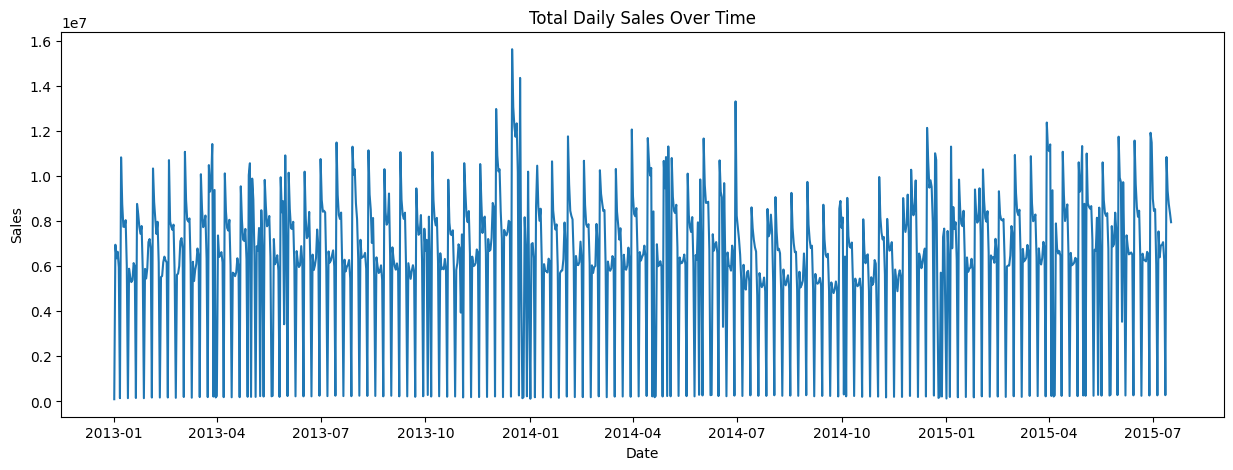

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df_agg['Date'], df_agg['Sales'])
plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

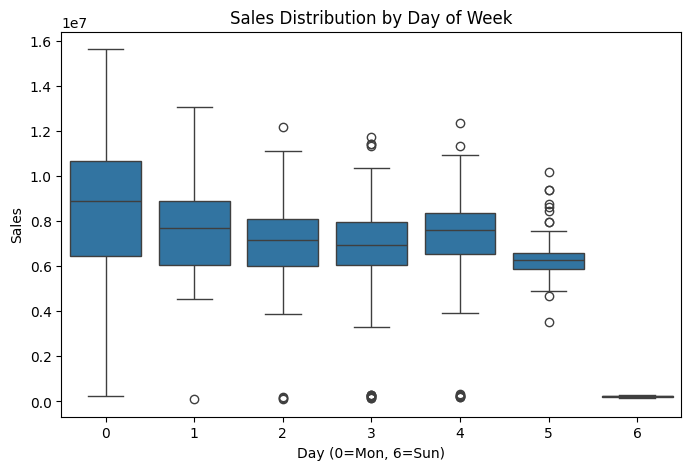

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='DayOfWeek', y='Sales', data=df_agg)
plt.title("Sales Distribution by Day of Week")
plt.xlabel("Day (0=Mon, 6=Sun)")
plt.show()

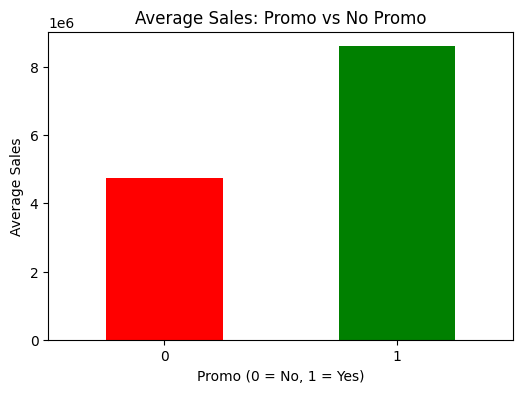

In [ ]:
promo_sales = df_agg.groupby('Promo')['Sales'].mean()

plt.figure(figsize=(6,4))
promo_sales.plot(kind='bar', color=['red', 'green'])
plt.title("Average Sales: Promo vs No Promo")
plt.xlabel("Promo (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.show()

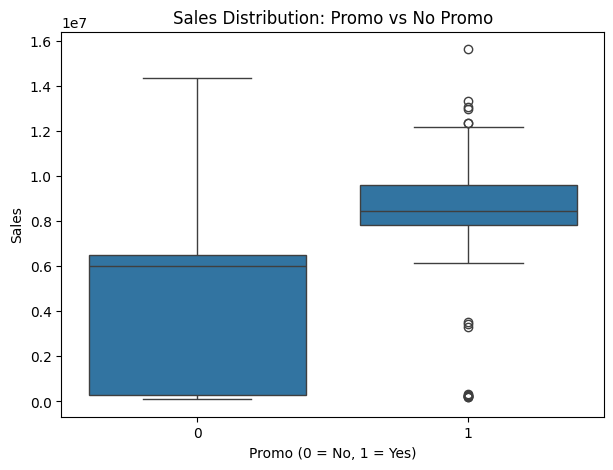

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Promo', y='Sales', data=df_agg)
plt.title("Sales Distribution: Promo vs No Promo")
plt.xlabel("Promo (0 = No, 1 = Yes)")
plt.ylabel("Sales")
plt.show()

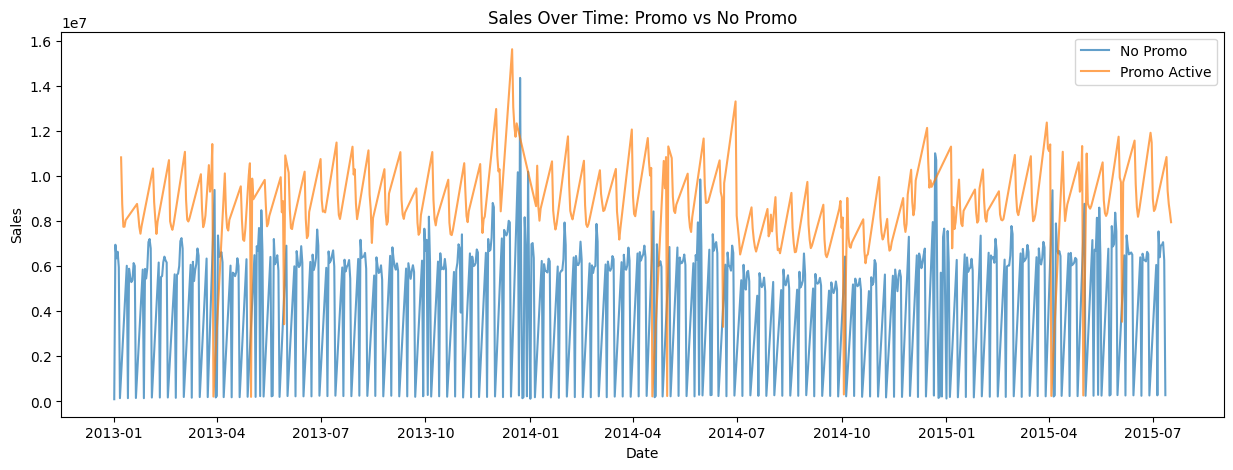

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df_agg[df_agg['Promo']==0]['Date'],
         df_agg[df_agg['Promo']==0]['Sales'],
         label='No Promo', alpha=0.7)

plt.plot(df_agg[df_agg['Promo']==1]['Date'],
         df_agg[df_agg['Promo']==1]['Sales'],
         label='Promo Active', alpha=0.7)

plt.title("Sales Over Time: Promo vs No Promo")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

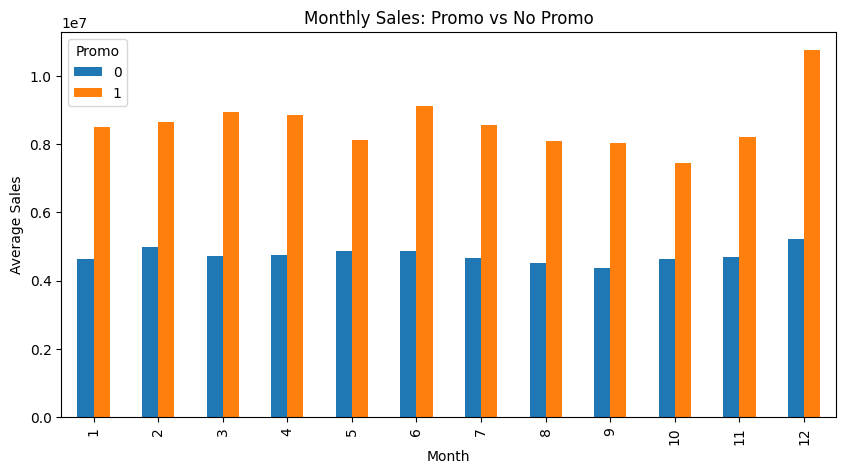

In [ ]:
monthly_promo = df_agg.groupby(['Month', 'Promo'])['Sales'].mean().unstack()

monthly_promo.plot(kind='bar', figsize=(10,5))
plt.title("Monthly Sales: Promo vs No Promo")
plt.ylabel("Average Sales")
plt.show()

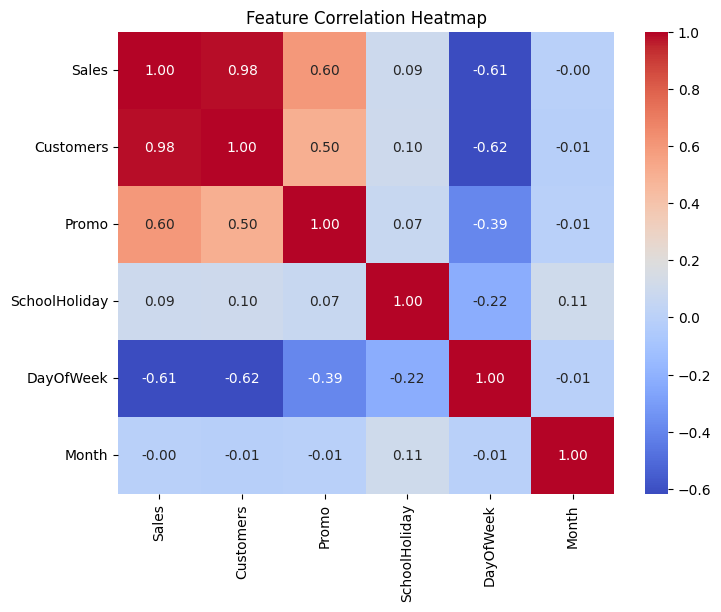

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_agg[['Sales','Customers','Promo','SchoolHoliday','DayOfWeek','Month']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

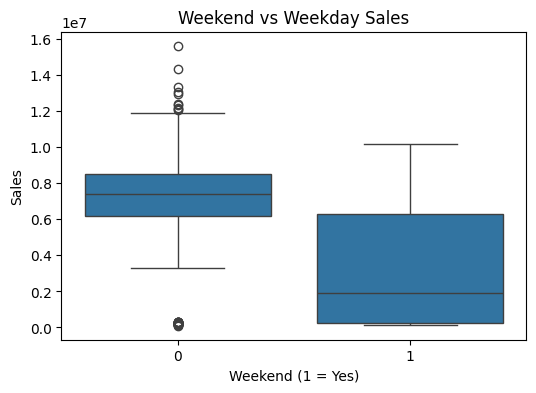

In [ ]:
df_agg['IsWeekend'] = df_agg['DayOfWeek'].isin([5,6]).astype(int)

plt.figure(figsize=(6,4))
sns.boxplot(x='IsWeekend', y='Sales', data=df_agg)
plt.title("Weekend vs Weekday Sales")
plt.xlabel("Weekend (1 = Yes)")
plt.show()

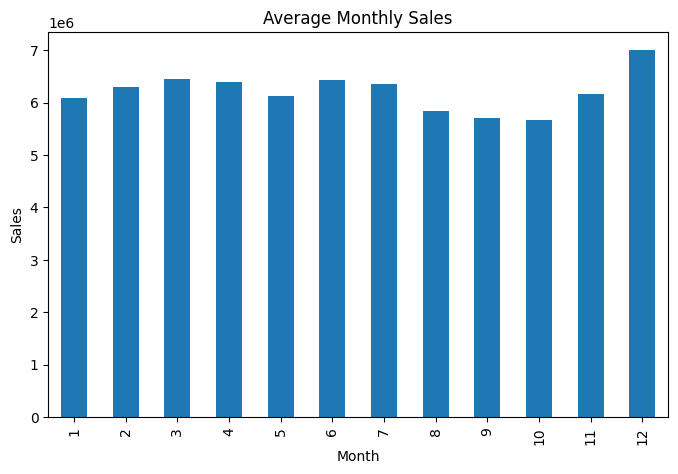

In [ ]:
monthly_sales = df_agg.groupby('Month')['Sales'].mean()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='bar')
plt.title("Average Monthly Sales")
plt.ylabel("Sales")
plt.show()

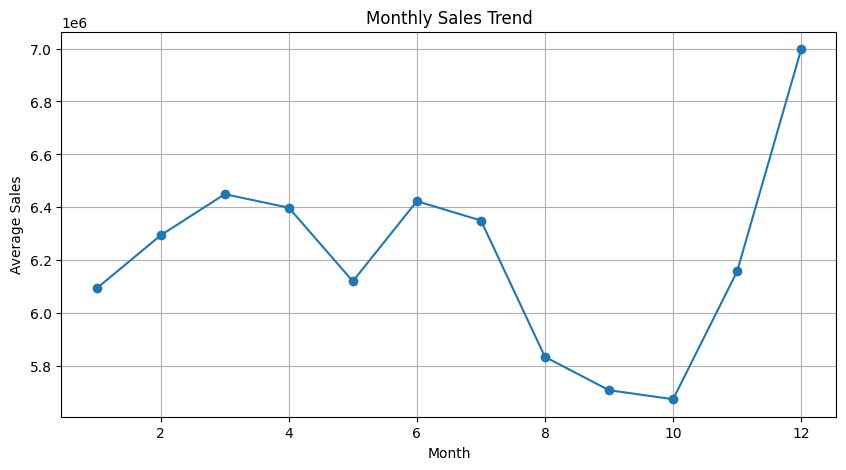

In [ ]:
monthly = df_agg.groupby('Month')['Sales'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid()
plt.show()

In [ ]:
df_agg = df_agg.sort_values('Date')

# LAG FEATURES
for lag in [1,7,14,28]:
    df_agg[f'lag_{lag}'] = df_agg['Sales'].shift(lag)

# ROLLING FEATURES
df_agg['rolling_mean_7'] = df_agg['Sales'].rolling(7).mean()
df_agg['rolling_std_7'] = df_agg['Sales'].rolling(7).std()

# CYCLICAL ENCODING
df_agg['dow_sin'] = np.sin(2*np.pi*df_agg['DayOfWeek']/7)
df_agg['dow_cos'] = np.cos(2*np.pi*df_agg['DayOfWeek']/7)

df_agg.dropna(inplace=True)
df_agg = df_agg.replace([np.inf, -np.inf], np.nan)
df_agg = df_agg.dropna().reset_index(drop=True)

ADF Statistic: -4.581468700857764
p-value: 0.00013971889737204136


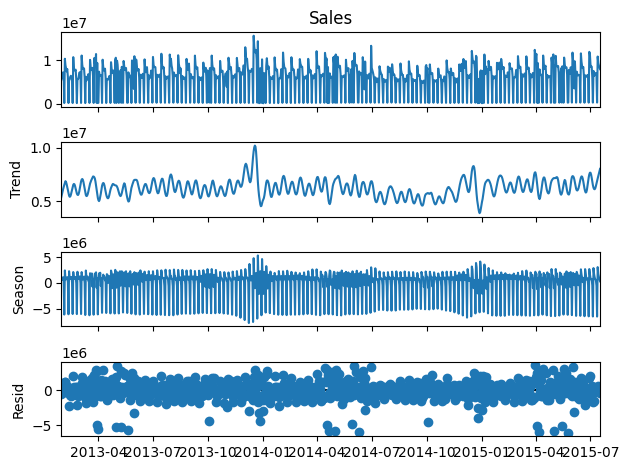

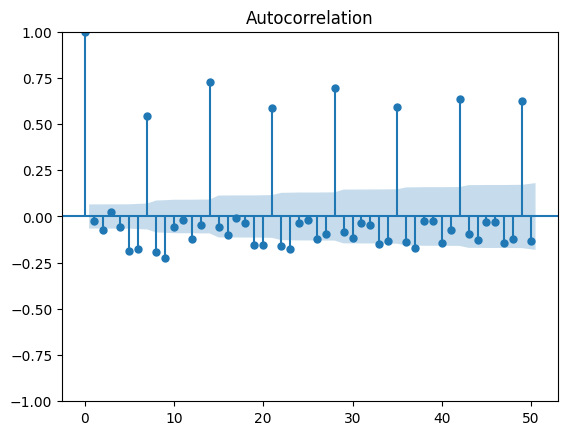

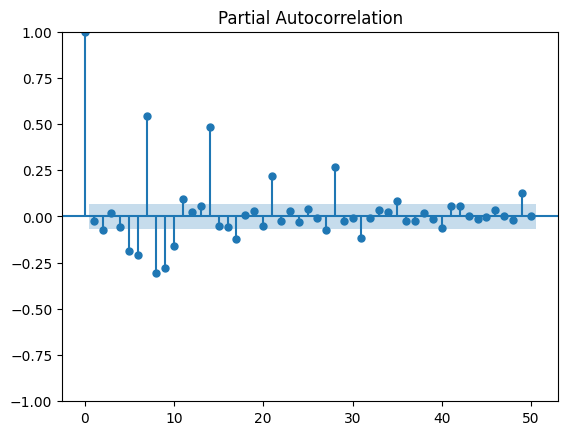

In [ ]:
# =========================================
# 📌 1. TIME SERIES PREP
# =========================================
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df_agg = df_agg.sort_values('Date')
df_agg.set_index('Date', inplace=True)
df_agg = df_agg.asfreq('D')

series = df_agg['Sales']

# ADF Test
result = adfuller(series.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# STL Decomposition
stl = STL(series, period=7)
res = stl.fit()
res.plot()
plt.show()

# ACF / PACF
plot_acf(series, lags=50)
plt.show()

plot_pacf(series, lags=50)
plt.show()


# =========================================
# 📌 2. TRAIN TEST SPLIT
# =========================================
train_size = int(len(series) * 0.8)

train = df_agg.iloc[:train_size]
test = df_agg.iloc[train_size:]

y_train = train['Sales']
y_test = test['Sales']

exog_cols = ['Promo','SchoolHoliday','IsWeekend',
             'lag_1','lag_7','lag_14','lag_28',
             'rolling_mean_7','rolling_std_7',
             'dow_sin','dow_cos']

exog_train = train[exog_cols]
exog_test = test[exog_cols]


# =========================================
# 📌 3. METRICS FUNCTION
# =========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred, k):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1-r2)*(n-1)/(n-k-1)

    return rmse, mae, mape, r2, adj_r2

def coverage_probability(y_true, lower, upper):
    inside = ((y_true >= lower) & (y_true <= upper)).astype(int)
    return inside.mean()

def compute_crps(y_true, mean, std):
    z = (y_true - mean) / (std + 1e-8)
    crps = std * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1/np.sqrt(np.pi))
    return np.mean(crps)

# =========================================
# 📌 4. MODEL RUN FUNCTION
# =========================================
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

results_list = []
models_dict = {}

# def run_model(name, model, y_train, y_test, exog_train=None, exog_test=None):

#     fitted = model.fit()

#     if exog_test is not None:
#         preds = fitted.predict(
#             start=len(y_train),
#             end=len(y_train)+len(y_test)-1,
#             exog=exog_test
#         )
#     else:
#         preds = fitted.predict(
#             start=len(y_train),
#             end=len(y_train)+len(y_test)-1
#         )

#     preds = pd.Series(preds, index=y_test.index)

#     rmse, mae, mape, r2, adj_r2 = evaluate_model(y_test, preds, len(fitted.params))

#     print(f"\n{name}")
#     print("RMSE:", rmse)
#     print("MAE:", mae)
#     print("MAPE:", mape)
#     print("R2:", r2)
#     print("Adj R2:", adj_r2)
#     print("AIC:", fitted.aic)

#     # Save results
#     results_list.append({
#         "Model": name,
#         "RMSE": rmse,
#         "MAE": mae,
#         "MAPE": mape,
#         "R2": r2,
#         "Adj_R2": adj_r2,
#         "AIC": fitted.aic
#     })

#     models_dict[name] = fitted

#     # Plot
#     plt.figure(figsize=(12,5))
#     plt.plot(y_test, label="Actual")
#     plt.plot(preds, label="Predicted")
#     plt.title(name)
#     plt.legend()
#     plt.show()

#     # Diagnostics
#     fitted.plot_diagnostics(figsize=(10,6))
#     plt.show()

In [ ]:
def run_model(name, model, y_train, y_test, exog_train=None, exog_test=None):

    fitted = model.fit()

    # =========================================
    # ✅ PROBABILISTIC MODELS
    # =========================================
    if name in ["ARIMA", "SARIMA", "ARIMAX", "SARIMAX"]:

        if exog_test is not None:
            forecast = fitted.get_forecast(
                steps=len(y_test),
                exog=exog_test
            )
        else:
            forecast = fitted.get_forecast(
                steps=len(y_test)
            )

        preds = forecast.predicted_mean
        conf_int = forecast.conf_int()

    # =========================================
    # ❌ OTHER MODELS (UNCHANGED)
    # =========================================
    else:
        if exog_test is not None:
            preds = fitted.predict(
                start=len(y_train),
                end=len(y_train)+len(y_test)-1,
                exog=exog_test
            )
        else:
            preds = fitted.predict(
                start=len(y_train),
                end=len(y_train)+len(y_test)-1
            )

        preds = pd.Series(preds, index=y_test.index)
        conf_int = None  # no uncertainty

    preds = pd.Series(preds, index=y_test.index)

    # =========================================
    # 📊 METRICS
    # =========================================
    rmse, mae, mape, r2, adj_r2 = evaluate_model(
        y_test, preds, len(fitted.params)
    )

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("MAPE:", mape)
    print("R2:", r2)
    print("Adj R2:", adj_r2)
    print("AIC:", fitted.aic if hasattr(fitted, "aic") else None)

    results_list.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "Adj_R2": adj_r2,
        "AIC": fitted.aic if hasattr(fitted, "aic") else None
    })

    models_dict[name] = fitted

    # =========================================
    # 📊 UNCERTAINTY METRICS (ONLY FOR PROB MODELS)
    # =========================================
    if conf_int is not None:

        lower = conf_int.iloc[:, 0]
        upper = conf_int.iloc[:, 1]

        # Coverage
        coverage = coverage_probability(y_test, lower, upper)

        # Std from CI (approx)
        std = (upper - lower) / (2 * 1.96)

        # CRPS
        crps = compute_crps(y_test.values, preds.values, std.values)

        print("Coverage (95%):", coverage)
        print("CRPS:", crps)

        # Save
        results_list[-1]["Coverage"] = coverage
        results_list[-1]["CRPS"] = crps

    else:
        results_list[-1]["Coverage"] = None
        results_list[-1]["CRPS"] = None

    # =========================================
    # 📈 PLOT
    # =========================================
    plt.figure(figsize=(12,5))

    plt.plot(y_test, label="Actual", color="black")
    plt.plot(preds, label="Prediction", color="blue")

    # ✅ Add uncertainty ONLY for probabilistic models
    if conf_int is not None:
        plt.fill_between(
            y_test.index,
            conf_int.iloc[:, 0],
            conf_int.iloc[:, 1],
            alpha=0.3,
            label="Confidence Interval"
        )

    plt.title(name)
    plt.legend()
    plt.grid()
    plt.show()

    # Diagnostics
    try:
        fitted.plot_diagnostics(figsize=(10,6))
        plt.show()
    except:
        pass


AR
RMSE: 3156748.970893725
MAE: 2407268.1780439964
MAPE: 402.2292936458405
R2: 0.029056561123598446
Adj R2: -0.01636769332675958
AIC: 23027.842284636954


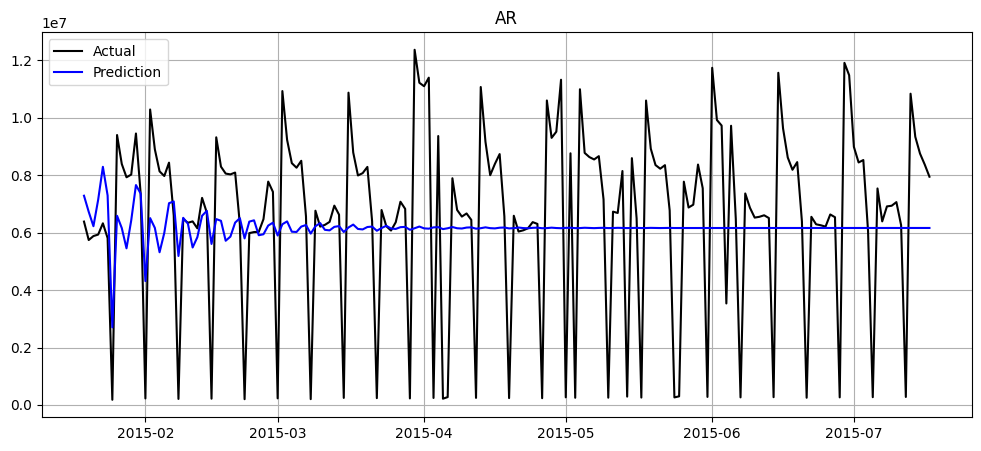

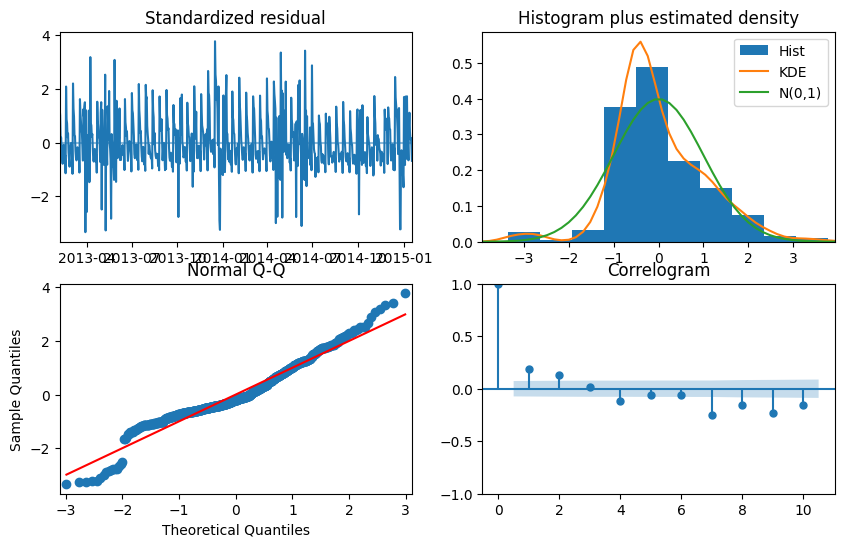

In [ ]:
# =========================================
# 📌 5. RUN ALL MODELS (MANUAL PARAMS)
# =========================================

# AR
run_model("AR", AutoReg(y_train, lags=7), y_train, y_test)


MA
RMSE: 3224814.2705850005
MAE: 2451457.532416907
MAPE: 421.2533315725616
R2: -0.013265486811820937
Adj R2: -0.06690895376068218
AIC: 23407.919006392127


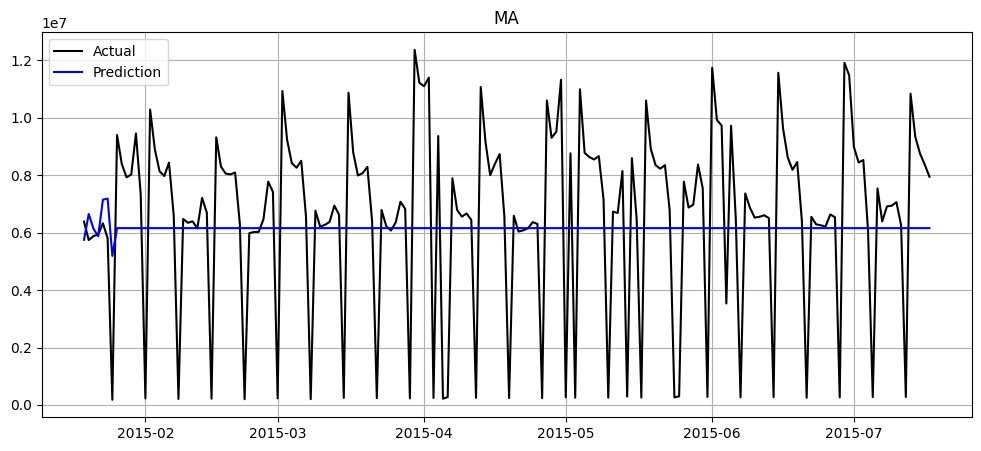

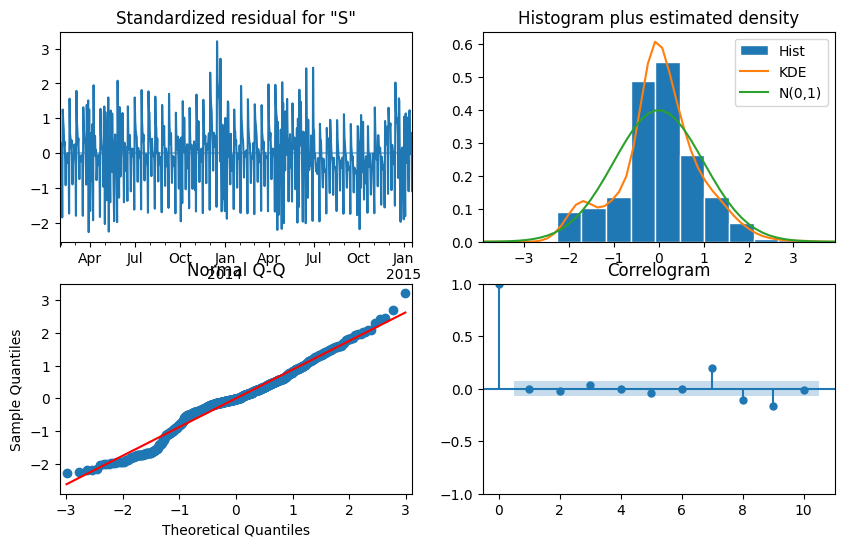

In [ ]:
# MA
run_model("MA", ARIMA(y_train, order=(0,0,7)), y_train, y_test)


ARMA
RMSE: 3121207.0426781755
MAE: 2380985.641235537
MAPE: 395.43958937209646
R2: 0.05079723944118886
Adj R2: -0.005368604378859221
AIC: 23216.668832762352


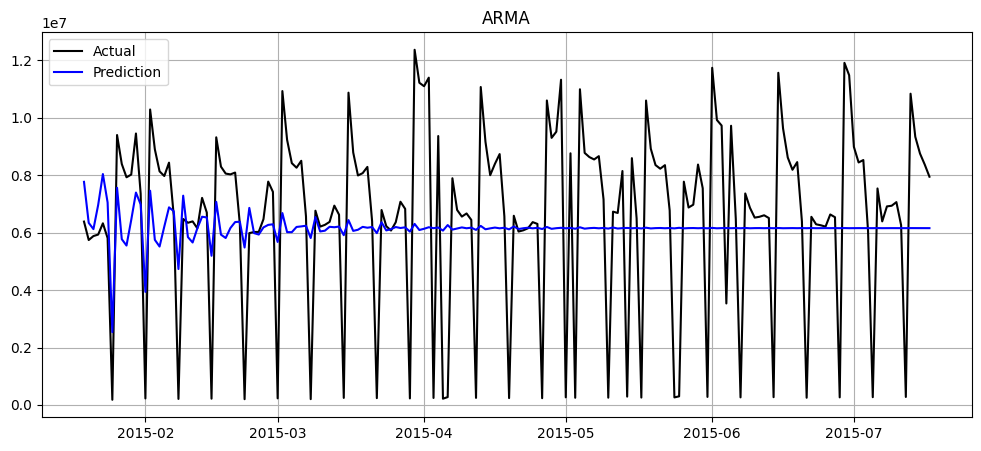

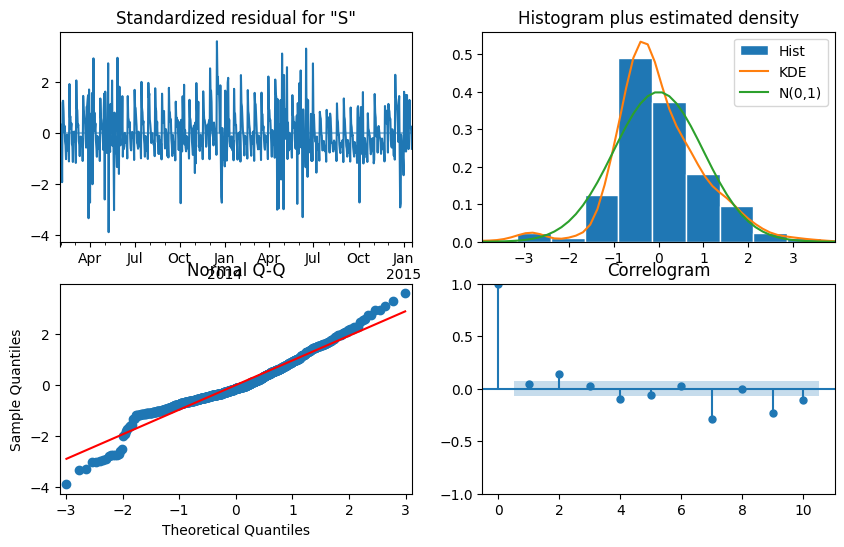

In [ ]:
# ARMA
run_model("ARMA", ARIMA(y_train, order=(7,0,1)), y_train, y_test)


ARIMA
RMSE: 3060917.114888511
MAE: 2229693.7818272063
MAPE: 406.2788713183633
R2: 0.08711309857396898
Adj R2: 0.038783792027884956
AIC: 23239.7272568384
Coverage (95%): 1.0
CRPS: 2174379.8621422728


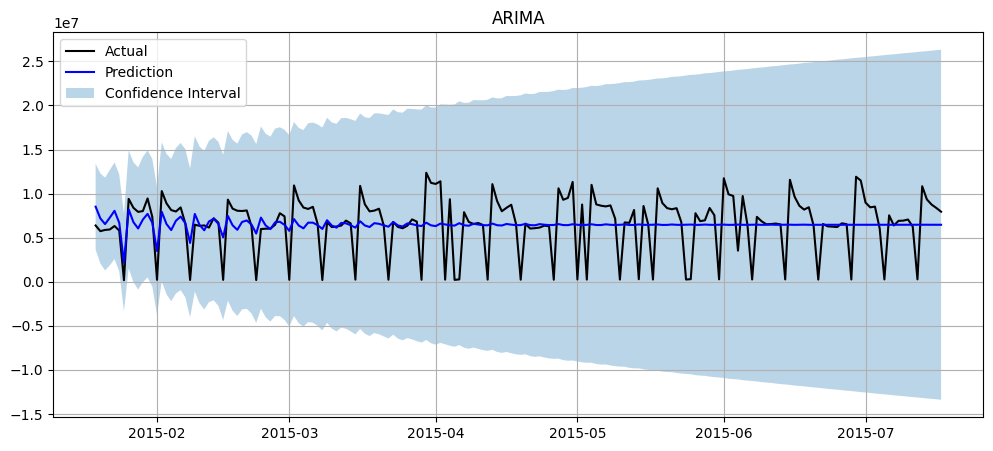

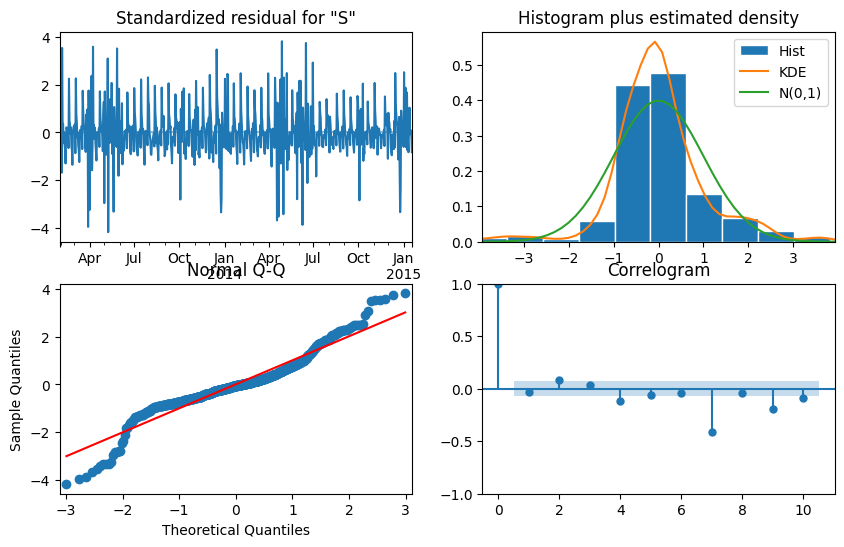

In [ ]:
# ARIMA
run_model("ARIMA", ARIMA(y_train, order=(7,1,1)), y_train, y_test)


SARIMA
RMSE: 2001502.2263250193
MAE: 1368639.154942135
MAPE: 157.20091615443775
R2: 0.6096753389311125
Adj R2: 0.5984591130383283
AIC: 22796.901152764294
Coverage (95%): 1.0
CRPS: 1555880.1593666424


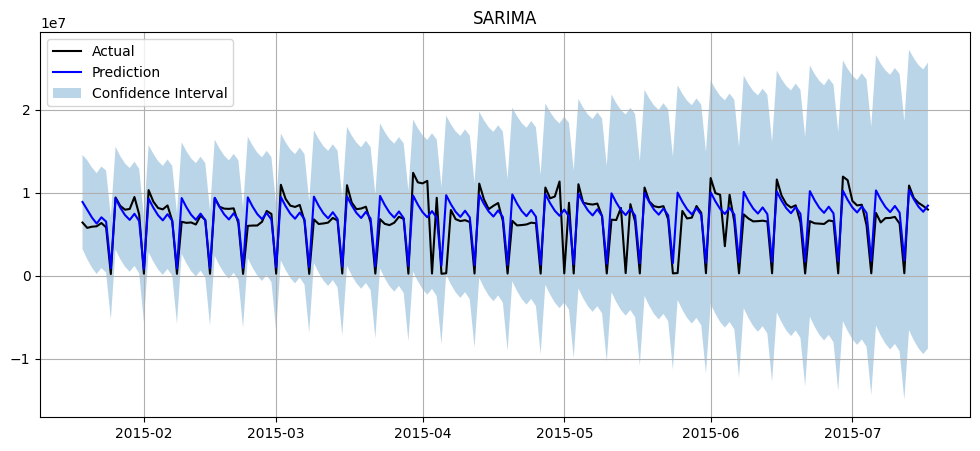

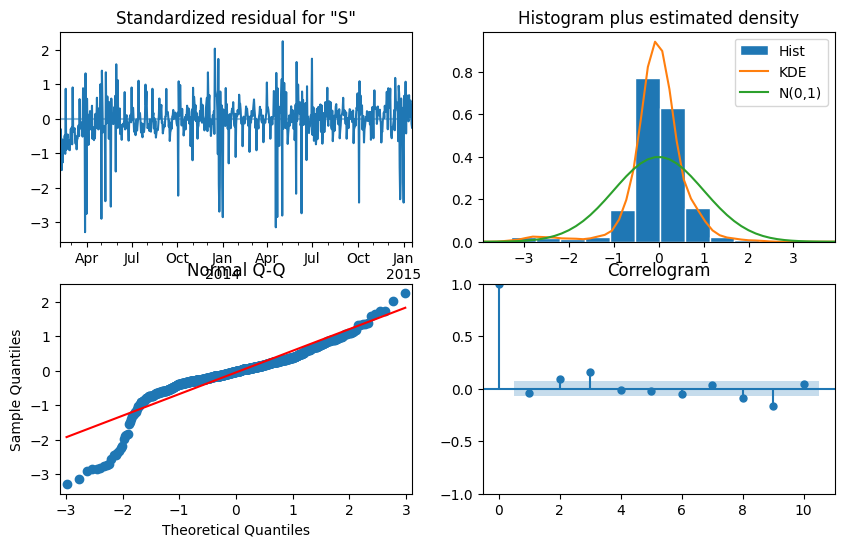

In [ ]:
# SARIMA
run_model("SARIMA", SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,7)),
          y_train, y_test)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



ARIMAX
RMSE: 1732666.9579317824
MAE: 1174882.2791356381
MAPE: 125.05507014993968
R2: 0.7074877737782126
Adj R2: 0.6706937830584909
AIC: 22536.479076311734
Coverage (95%): 0.9388888888888889
CRPS: 902002.2492791353


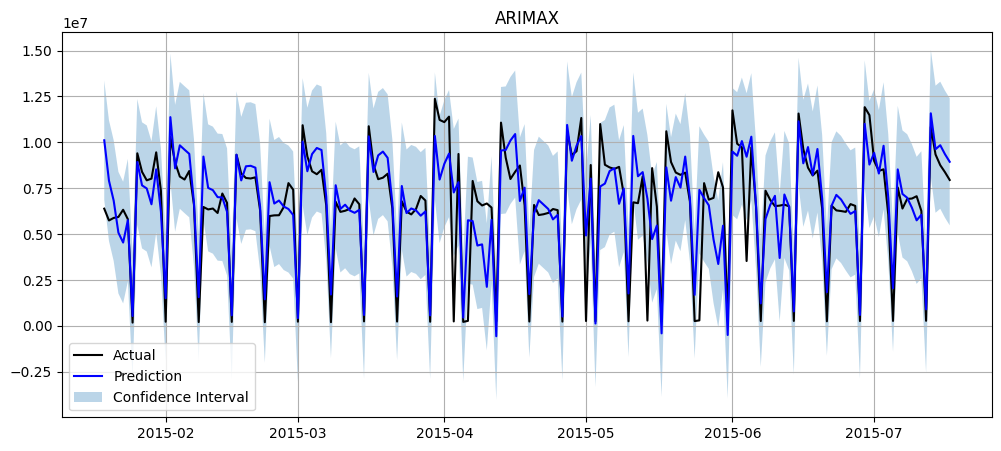

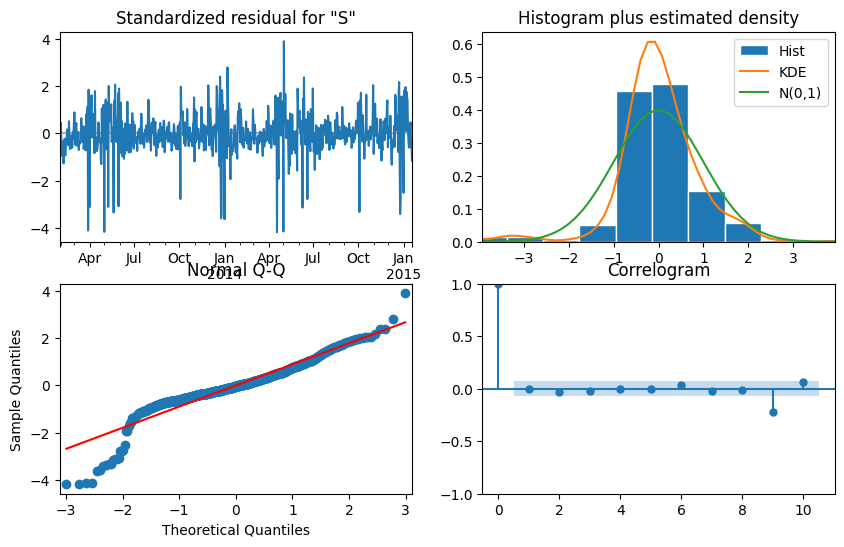

In [ ]:
# ARIMAX
run_model("ARIMAX", ARIMA(y_train, order=(7,1,1), exog=exog_train),
          y_train, y_test, exog_train, exog_test)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



SARIMAX
RMSE: 1625477.6379295036
MAE: 1158281.8164510215
MAPE: 117.3265025383279
R2: 0.7425601139047425
Adj R2: 0.7172899410364963
AIC: 22307.246073089067
Coverage (95%): 0.9666666666666667
CRPS: 906082.4446185846


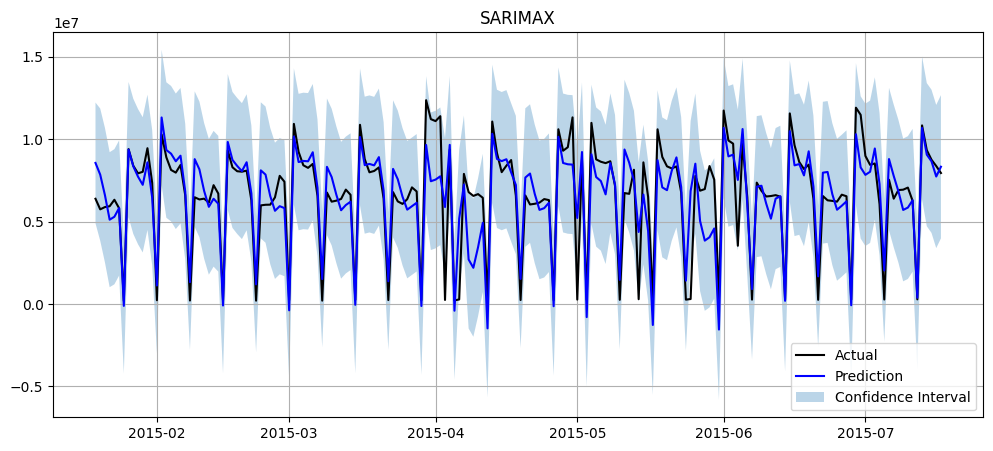

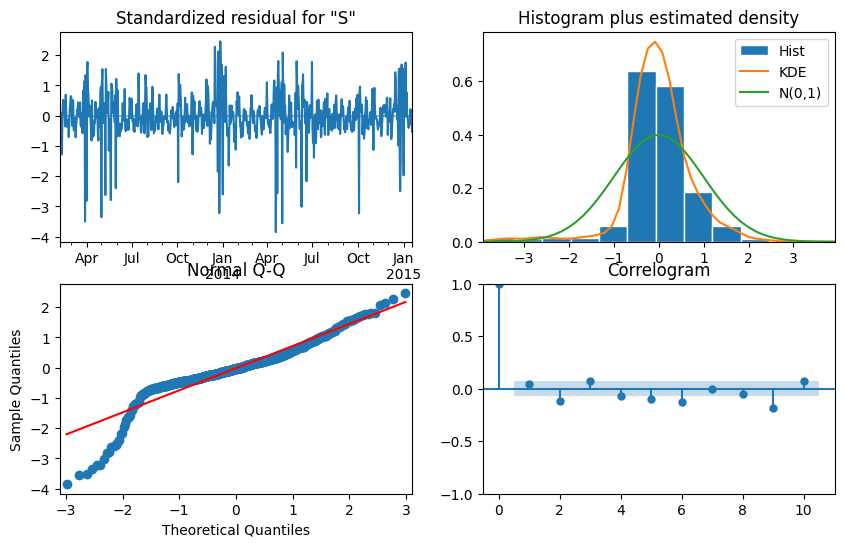

In [ ]:
# SARIMAX
run_model("SARIMAX", SARIMAX(y_train, exog=exog_train,
          order=(1,1,1), seasonal_order=(1,1,1,7)),
          y_train, y_test, exog_train, exog_test)


Prophet
RMSE: 1619993.502517396
MAE: 964451.3281546388
MAPE: 85.38853647155388
R2: 0.7442943162033998
Adj R2: 0.7369464517264861
Coverage (95%): 0.8722222222222222
CRPS: 775093.9877993532


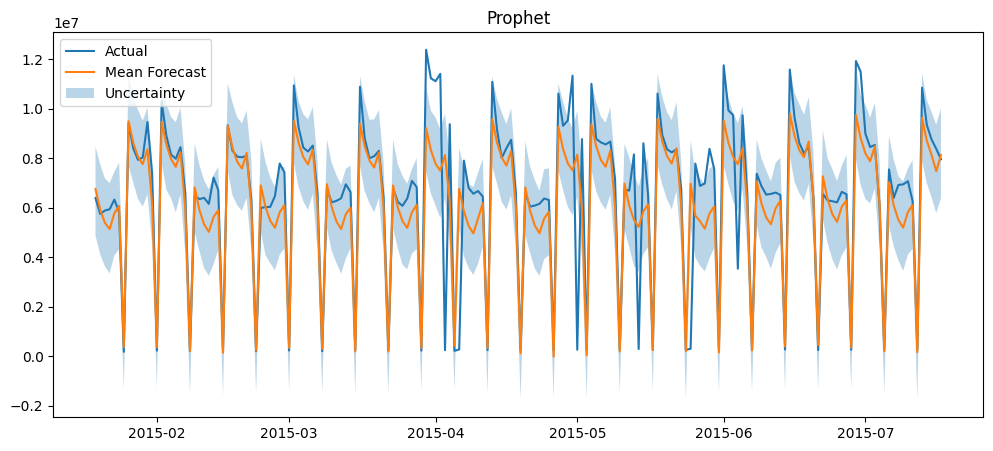

In [ ]:
# =========================================
# 📌 6. PROPHET MODEL (FIXED)
# =========================================

df_prophet = df_agg.reset_index()[['Date','Sales','Promo','SchoolHoliday']]
df_prophet.columns = ['ds','y','Promo','SchoolHoliday']

train_p = df_prophet.iloc[:train_size]
test_p = df_prophet.iloc[train_size:]

model_p = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
    seasonality_mode='multiplicative'
)

# add regressors
model_p.add_regressor('Promo')
model_p.add_regressor('SchoolHoliday')

# fit model
model_p.fit(train_p)

# =========================================
# 📌 FIX: future dataframe MUST contain regressors
# =========================================
future = model_p.make_future_dataframe(periods=len(test_p))

# attach regressors properly (IMPORTANT FIX)
future = future.merge(
    df_prophet[['ds','Promo','SchoolHoliday']],
    on='ds',
    how='left'
)

# if any missing values appear after merge → fill safely
future['Promo'] = future['Promo'].fillna(0)
future['SchoolHoliday'] = future['SchoolHoliday'].fillna(0)

# predict
forecast = model_p.predict(future)

# =========================================
# 📌 FIX: correct slicing
# =========================================
preds = forecast['yhat'].iloc[-len(test_p):].values
lower = forecast['yhat_lower'].iloc[-len(test_p):].values
upper = forecast['yhat_upper'].iloc[-len(test_p):].values
# evaluation
rmse, mae, mape, r2, adj_r2 = evaluate_model(
    test_p['y'].values,
    preds,
    k=5  # rough estimate
)

print("\nProphet")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)
print("R2:", r2)
print("Adj R2:", adj_r2)

coverage = coverage_probability(
    test_p['y'].values,
    lower,
    upper
)

std = (upper - lower) / (2 * 1.96)

crps = compute_crps(
    test_p['y'].values,
    preds,
    std
)

print("Coverage (95%):", coverage)
print("CRPS:", crps)

results_list.append({
    "Model": "Prophet",
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape,
    "R2": r2,
    "Adj_R2": adj_r2,
    "AIC": None,
    "Coverage": coverage,
    "CRPS": crps
})

models_dict["Prophet"] = model_p

# plot
# plt.figure(figsize=(12,5))
# plt.plot(test_p['ds'], test_p['y'].values, label="Actual")
# plt.plot(test_p['ds'], preds, label="Predicted")
# plt.title("Prophet")
# plt.legend()
# plt.show()
plt.figure(figsize=(12,5))

plt.plot(test_p['ds'], test_p['y'].values, label="Actual")
plt.plot(test_p['ds'], preds, label="Mean Forecast")

plt.fill_between(
    test_p['ds'],
    lower,
    upper,
    alpha=0.3,
    label="Uncertainty"
)

plt.title("Prophet")
plt.legend()
plt.show()

In [ ]:
!pip install tbats


Fitting TBATS model... (this may take time)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



TBATS
RMSE: 1975858.6631746152
MAE: 1366431.6738075989
MAPE: 96.75752355012628
R2: 0.6196130692021706
Adj R2: 0.6086824102711985


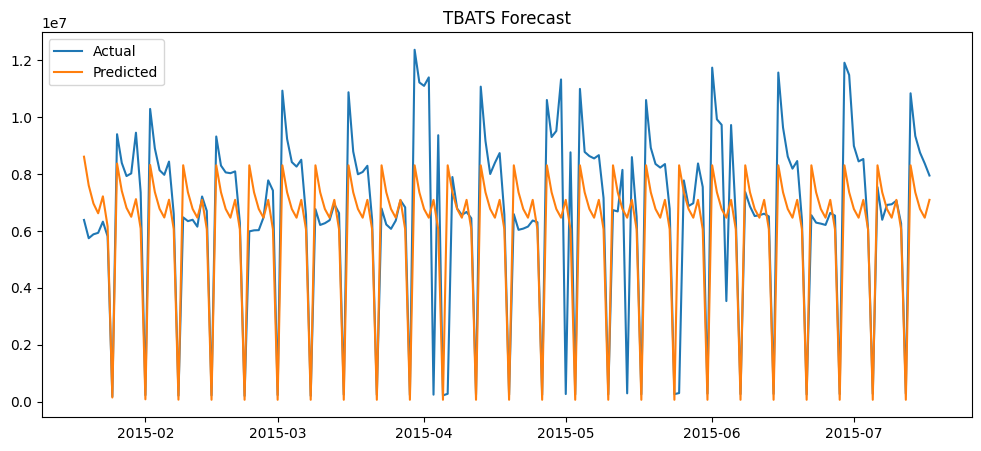

In [ ]:
# =========================================
# 📌 TBATS MODEL
# =========================================
from tbats import TBATS

# TBATS works only on 1D series (no exog)
tbats_series_train = y_train.copy()
tbats_series_test = y_test.copy()

# Define TBATS estimator
estimator = TBATS(
    seasonal_periods=[7],   # weekly seasonality (important for Rossmann data)
    use_box_cox=False,
    use_trend=True,
    use_damped_trend=True,
    show_warnings=False
)

print("\nFitting TBATS model... (this may take time)")
tbats_model = estimator.fit(tbats_series_train)

# Forecast
tbats_pred = tbats_model.forecast(steps=len(tbats_series_test))

tbats_pred = pd.Series(tbats_pred, index=tbats_series_test.index)

# Evaluate using your existing function
rmse, mae, mape, r2, adj_r2 = evaluate_model(
    tbats_series_test,
    tbats_pred,
    k=tbats_model.state_space_model.shape[0] if hasattr(tbats_model, "state_space_model") else 5
)

print("\nTBATS")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)
print("R2:", r2)
print("Adj R2:", adj_r2)

# Save results (same format as others)
results_list.append({
    "Model": "TBATS",
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape,
    "R2": r2,
    "Adj_R2": adj_r2,
    "AIC": None
})

models_dict["TBATS"] = tbats_model

# Plot
plt.figure(figsize=(12,5))
plt.plot(tbats_series_test, label="Actual")
plt.plot(tbats_pred, label="Predicted")
plt.title("TBATS Forecast")
plt.legend()
plt.show()

In [ ]:
# =========================================
# 📌 7. FINAL RESULTS TABLE
# =========================================
results_df = pd.DataFrame(results_list)

results_df = results_df.sort_values("RMSE")

print("\nFinal Model Comparison:")
display(results_df)


Final Model Comparison:


,Model,RMSE,MAE,MAPE,R2,Adj_R2,AIC,Coverage,CRPS
7,Prophet,1.619994e+06,9.644513e+05,85.388536,0.744294,0.736946,NaN,0.872222,7.750940e+05
6,SARIMAX,1.625478e+06,1.158282e+06,117.326503,0.742560,0.717290,22307.246073,0.966667,9.060824e+05
5,ARIMAX,1.732667e+06,1.174882e+06,125.055070,0.707488,0.670694,22536.479076,0.938889,9.020022e+05
8,TBATS,1.975859e+06,1.366432e+06,96.757524,0.619613,0.608682,NaN,NaN,NaN
4,SARIMA,2.001502e+06,1.368639e+06,157.200916,0.609675,0.598459,22796.901153,1.000000,1.555880e+06
3,ARIMA,3.060917e+06,2.229694e+06,406.278871,0.087113,0.038784,23239.727257,1.000000,2.174380e+06
2,ARMA,3.121207e+06,2.380986e+06,395.439589,0.050797,-0.005369,23216.668833,NaN,NaN
0,AR,3.156749e+06,2.407268e+06,402.229294,0.029057,-0.016368,23027.842285,NaN,NaN
1,MA,3.224814e+06,2.451458e+06,421.253332,-0.013265,-0.066909,23407.919006,NaN,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle
import os

save_path = "/content/drive/MyDrive/saved_models"
os.makedirs(save_path, exist_ok=True)

for name, model in models_dict.items():
    with open(f"{save_path}/{name}.pkl", "wb") as f:
        pickle.dump(model, f)

print("Models saved to Google Drive")

Models saved to Google Drive


In [ ]:
# =========================================
# 📌 8. EXPORT MODELS
# =========================================
import pickle
import os

os.makedirs("saved_models", exist_ok=True)

for name, model in models_dict.items():
    with open(f"saved_models/{name}.pkl", "wb") as f:
        pickle.dump(model, f)

print("\nAll models saved in 'saved_models/' folder")


All models saved in 'saved_models/' folder


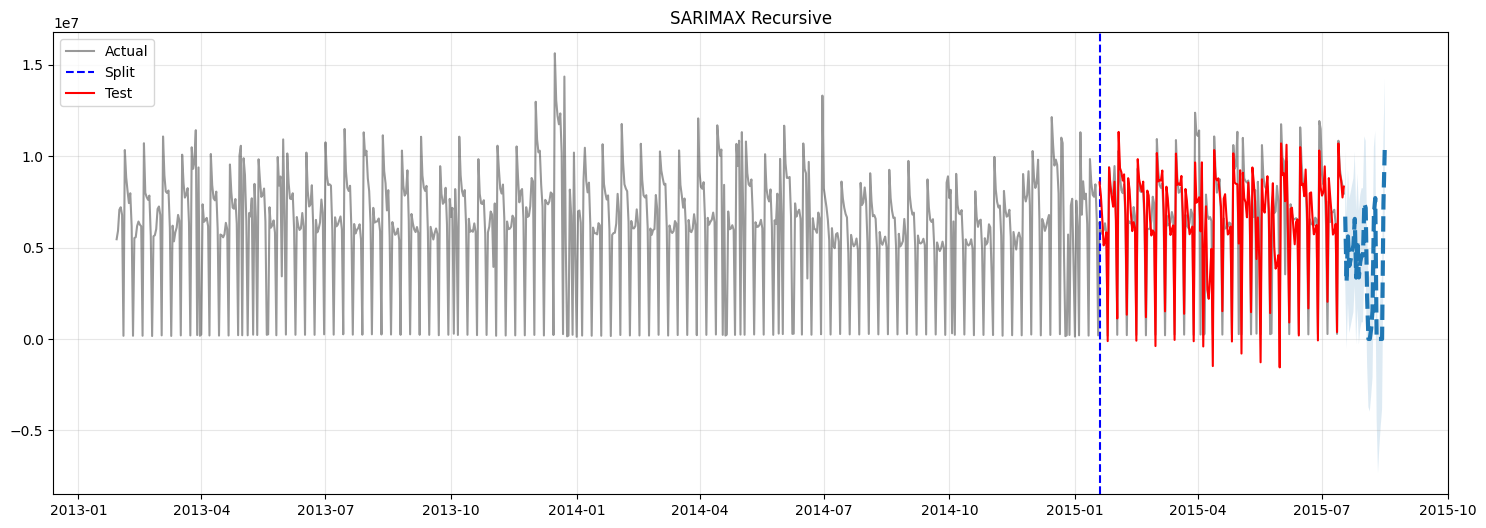

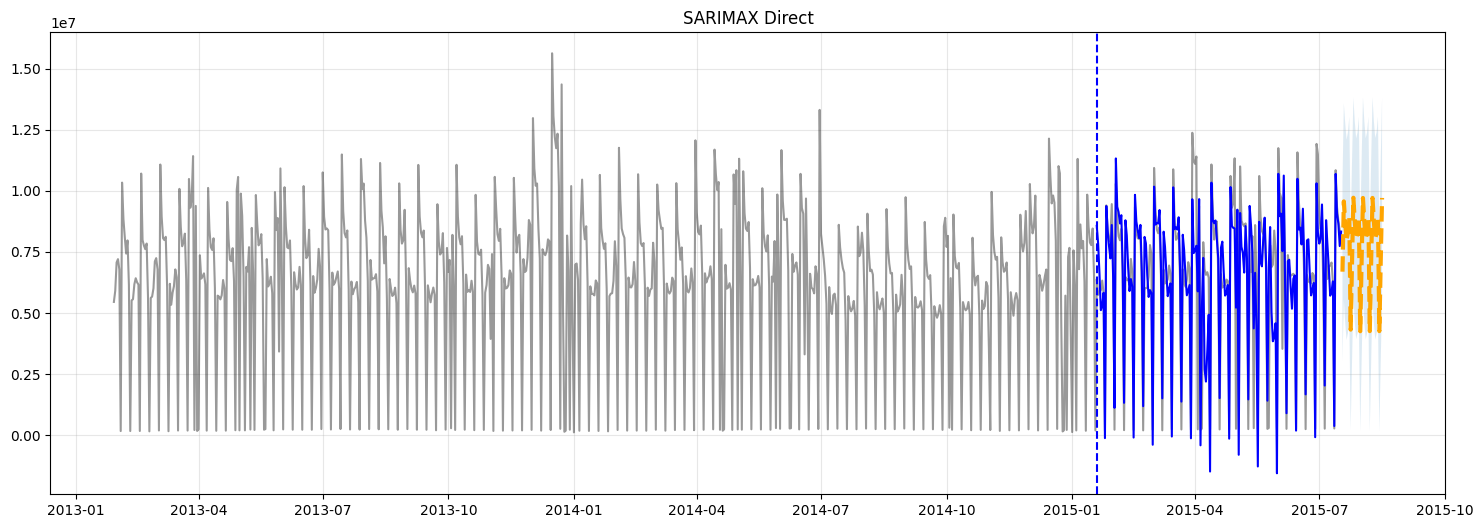

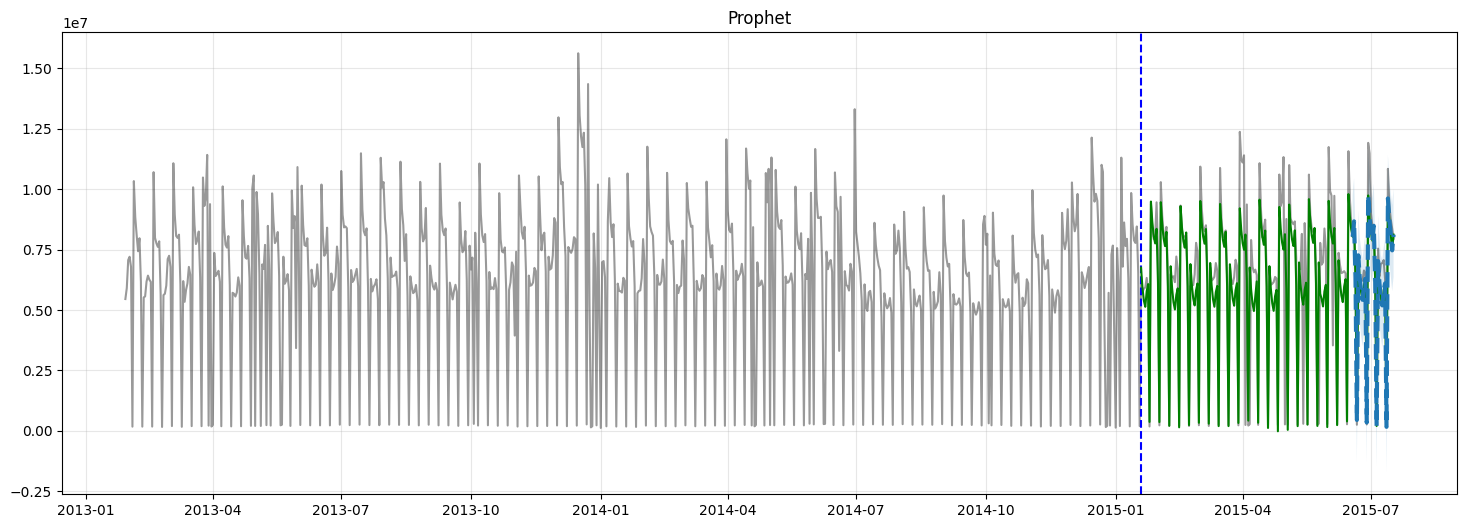

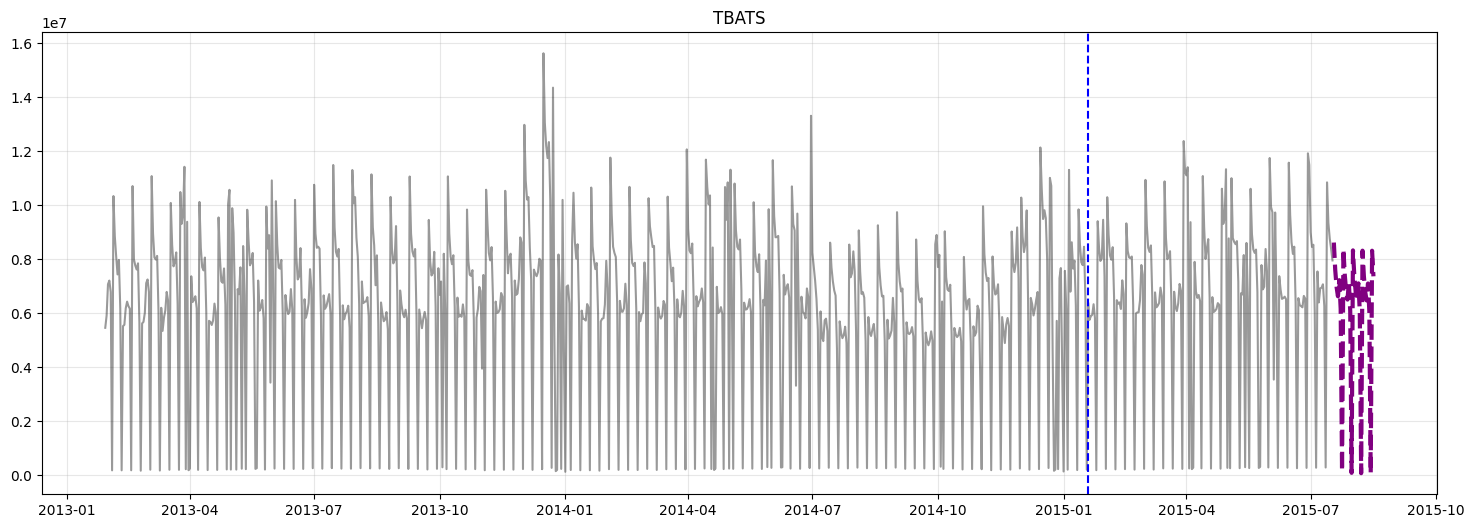

In [ ]:
# =========================================
# SARIMAX + PROPHET + FUTURE FORECAST (30 DAYS)
# FINAL CLEAN VERSION (ORDER FIXED ONLY)
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# SETTINGS
# -----------------------------
future_steps = 30

# -----------------------------
# FUTURE DATE INDEX
# -----------------------------
future_index = pd.date_range(
    start=df_agg.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq="D"
)

# -----------------------------
# SARIMAX MODEL
# -----------------------------
sarimax_model = models_dict["SARIMAX"]

# =========================================================
# 1. SARIMAX TEST PREDICTIONS
# =========================================================
sarimax_test_pred = sarimax_model.predict(
    start=train_size,
    end=len(df_agg) - 1,
    exog=exog_test
)
sarimax_test_pred = pd.Series(sarimax_test_pred, index=test.index)


# =========================================================
# 2. SARIMAX RECURSIVE FORECAST (ORIGINAL)
# =========================================================
history = df_agg.copy()

future_preds = []
future_ci_lower = []
future_ci_upper = []

for i in range(future_steps):

    next_date = history.index[-1] + pd.Timedelta(days=1)

    row = {}

    # Calendar
    dow = next_date.dayofweek
    row['IsWeekend'] = int(dow >= 5)
    row['dow_sin'] = np.sin(2*np.pi*dow/7)
    row['dow_cos'] = np.cos(2*np.pi*dow/7)

    # Assumptions
    row['Promo'] = 0
    row['SchoolHoliday'] = 0

    # Lag features
    row['lag_1']  = history['Sales'].iloc[-1]
    row['lag_7']  = history['Sales'].iloc[-7]
    row['lag_14'] = history['Sales'].iloc[-14]
    row['lag_28'] = history['Sales'].iloc[-28]

    # Rolling
    row['rolling_mean_7'] = history['Sales'].iloc[-7:].mean()
    row['rolling_std_7']  = history['Sales'].iloc[-7:].std()

    exog_row = pd.DataFrame(row, index=[next_date])

    fc = sarimax_model.get_forecast(steps=1, exog=exog_row)

    pred = fc.predicted_mean.iloc[0]
    pred = max(pred, 0)
    ci = fc.conf_int().iloc[0]

    future_preds.append(pred)
    future_ci_lower.append(ci.iloc[0])
    future_ci_upper.append(ci.iloc[1])

    history.loc[next_date, 'Sales'] = pred

sarimax_future_pred = pd.Series(future_preds, index=future_index)
sarimax_future_ci = pd.DataFrame({
    "lower": future_ci_lower,
    "upper": future_ci_upper
}, index=future_index)


# =========================================================
# 3. SARIMAX DIRECT FORECAST
# =========================================================
future_exog_direct = []
history = df_agg.copy()

for i in range(future_steps):

    next_date = history.index[-1] + pd.Timedelta(days=1)
    dow = next_date.dayofweek

    row = {}

    row['IsWeekend'] = int(dow >= 5)
    row['dow_sin'] = np.sin(2*np.pi*dow/7)
    row['dow_cos'] = np.cos(2*np.pi*dow/7)

    row['Promo'] = 0
    row['SchoolHoliday'] = 0

    row['lag_1']  = history['Sales'].iloc[-1]
    row['lag_7']  = history['Sales'].iloc[-7]
    row['lag_14'] = history['Sales'].iloc[-14]
    row['lag_28'] = history['Sales'].iloc[-28]

    row['rolling_mean_7'] = history['Sales'].iloc[-7:].mean()
    row['rolling_std_7']  = history['Sales'].iloc[-7:].std()

    future_exog_direct.append(row)

future_exog_direct = pd.DataFrame(future_exog_direct, index=future_index)

sarimax_direct_fc = sarimax_model.get_forecast(
    steps=future_steps,
    exog=future_exog_direct
)

sarimax_direct_pred = sarimax_direct_fc.predicted_mean
sarimax_direct_ci = sarimax_direct_fc.conf_int()


# =========================================================
# 4. PROPHET
# =========================================================
prophet_forecast_df = forecast.copy()

prophet_test_pred = prophet_forecast_df[['ds', 'yhat']].iloc[-len(test):]
prophet_test_pred = prophet_test_pred.set_index("ds")

prophet_future = prophet_forecast_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(future_steps)
prophet_future = prophet_future.set_index("ds")


# =========================================================
# 5. TBATS
# =========================================================
tbats_model = models_dict["TBATS"]

tbats_future_pred = tbats_model.forecast(steps=future_steps)
tbats_future_pred = pd.Series(tbats_future_pred, index=future_index)


# =========================================================
# 6. PLOTS
# =========================================================

# ---- SARIMAX RECURSIVE ----
plt.figure(figsize=(18,6))
plt.plot(df_agg.index, df_agg["Sales"], color="black", alpha=0.4, label="Actual")
plt.axvline(df_agg.index[train_size], color="blue", linestyle="--", label="Split")
plt.plot(test.index, sarimax_test_pred, color="red", label="Test")
plt.fill_between(sarimax_future_ci.index, sarimax_future_ci["lower"], sarimax_future_ci["upper"], alpha=0.15)
plt.plot(sarimax_future_pred.index, sarimax_future_pred, linestyle="--", linewidth=3)
plt.title("SARIMAX Recursive")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ---- SARIMAX DIRECT ----
plt.figure(figsize=(18,6))
plt.plot(df_agg.index, df_agg["Sales"], color="black", alpha=0.4)
plt.axvline(df_agg.index[train_size], color="blue", linestyle="--")
plt.plot(test.index, sarimax_test_pred, color="blue")
plt.plot(future_index, sarimax_direct_pred, color="orange", linestyle="--", linewidth=3)
plt.fill_between(future_index, sarimax_direct_ci.iloc[:,0], sarimax_direct_ci.iloc[:,1], alpha=0.15)
plt.title("SARIMAX Direct")
plt.grid(alpha=0.3)
plt.show()


# ---- PROPHET ----
plt.figure(figsize=(18,6))
plt.plot(df_agg.index, df_agg["Sales"], color="black", alpha=0.4)
plt.axvline(df_agg.index[train_size], color="blue", linestyle="--")
plt.plot(prophet_test_pred.index, prophet_test_pred["yhat"], color="green")
plt.fill_between(prophet_future.index, prophet_future["yhat_lower"], prophet_future["yhat_upper"], alpha=0.15)
plt.plot(prophet_future.index, prophet_future["yhat"], linestyle="--", linewidth=3)
plt.title("Prophet")
plt.grid(alpha=0.3)
plt.show()


# ---- TBATS ----
plt.figure(figsize=(18,6))
plt.plot(df_agg.index, df_agg["Sales"], color="black", alpha=0.4)
plt.axvline(df_agg.index[train_size], color="blue", linestyle="--")
plt.plot(future_index, tbats_future_pred, color="purple", linestyle="--", linewidth=3)
plt.title("TBATS")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
df_agg.reset_index().to_csv("df_agg.csv", index=False)
results_df.to_csv("results.csv", index=False)